## Task 1 — Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('train.csv', encoding='latin1')
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df['Order Date'].head(10).tolist()

['08/11/2017',
 '08/11/2017',
 '12/06/2017',
 '11/10/2016',
 '11/10/2016',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015',
 '09/06/2015']

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

print("Order date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Ship date range :", df['Ship Date'].min(), "to", df['Ship Date'].max())

Order date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Ship date range : 2015-01-07 00:00:00 to 2019-01-05 00:00:00


In [5]:
# time features 
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Fall
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Fall
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Fall
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Fall


In [6]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Postal Code    11
dtype: int64

Duplicate rows: 0


In [7]:
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
print("Weekly points:", weekly_sales.shape[0], "| Monthly points:", monthly_sales.shape[0])
monthly_sales.head()

Weekly points: 209 | Monthly points: 48


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Q1. Which product category generates the highest total revenue?

In [8]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

**Technology (₹8,27,456)** brings in the most revenue, just ahead of Furniture
(₹7,28,659) and Office Supplies (₹7,05,422). It's closer than I expected — all three
categories are within about 15% of each other, so this isn't a business that lives or
dies on one category, it's fairly balanced.

### Q2. Which region has the most consistent sales growth over 4 years?

In [9]:
region_year = df.groupby(['Region', 'Year'])['Sales'].sum().reset_index()
region_pivot = region_year.pivot(index='Year', columns='Region', values='Sales')
region_pivot

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


In [10]:
pct_change = region_pivot.pct_change().dropna()
print("Year-over-year % change:")
print(pct_change.round(3))
print("\nStd dev of YoY change (lower = steadier growth):")
print(pct_change.std().sort_values())

Year-over-year % change:
Region  Central   East  South   West
Year                                
2016     -0.005  0.200 -0.322 -0.084
2017      0.422  0.165  0.335  0.365
2018     -0.028  0.177  0.306  0.360

Std dev of YoY change (lower = steadier growth):


Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


### Q3. Average time between Order Date and Ship Date — does it vary by region?

In [11]:
df['ShipGap'] = (df['Ship Date'] - df['Order Date']).dt.days
print("Overall average shipping gap:", round(df['ShipGap'].mean(), 2), "days")

Overall average shipping gap: 3.96 days


In [12]:
df.groupby('Region')['ShipGap'].mean().sort_values(ascending=False).round(2)

Region
Central    4.07
South      3.96
West       3.93
East       3.91
Name: ShipGap, dtype: float64

In [13]:
df.groupby('Ship Mode')['ShipGap'].mean().sort_values(ascending=False).round(2)

Ship Mode
Standard Class    5.01
Second Class      3.25
First Class       2.18
Same Day          0.04
Name: ShipGap, dtype: float64

Overall it's about **3.96 days**, and honestly it barely moves by region — Central is
the slowest at 4.07 days and East is fastest at 3.91 days, a gap of less than 2 hours on
average, basically noise. What actually drives the gap is **Ship Mode**, not region:
Same Day is ~0 days (makes sense) while Standard Class averages 5 days, so shipping
speed is a customer choice at checkout, not a regional logistics issue.

### Q4. Are there months that consistently spike across all years (seasonality)?

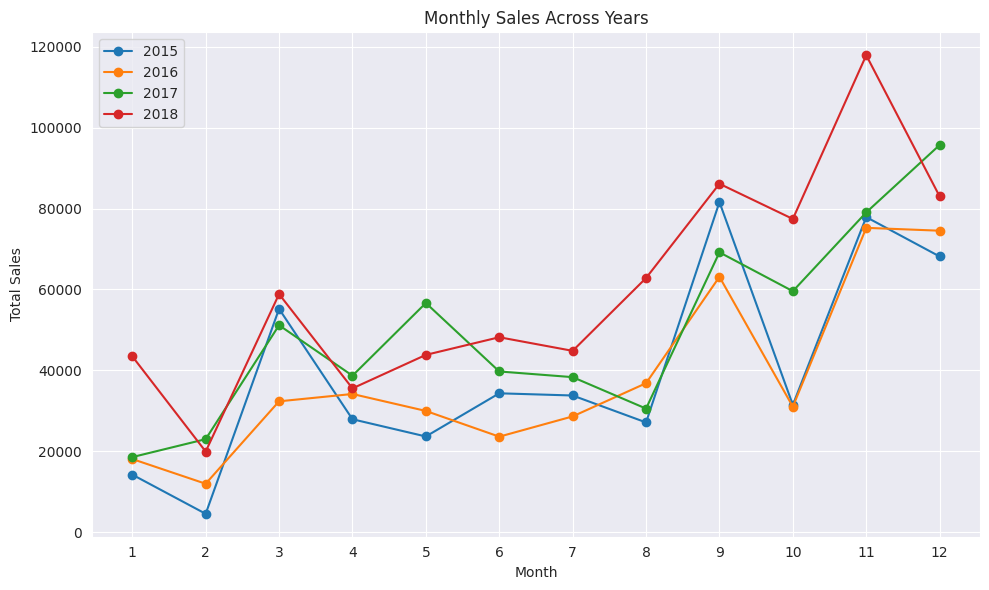

In [14]:
month_year = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
pivot_my = month_year.pivot(index='Month', columns='Year', values='Sales')

plt.figure(figsize=(10, 6))
for year in pivot_my.columns:
    plt.plot(pivot_my.index, pivot_my[year], marker='o', label=str(year))
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Across Years')
plt.legend()
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('charts/task1_seasonality.png', dpi=110)
plt.show()

In [15]:
avg_by_month = pivot_my.mean(axis=1).sort_values(ascending=False)
avg_by_month.round(0)

Month
11    87540.0
12    80370.0
9     75026.0
10    49874.0
3     49393.0
8     39329.0
5     38522.0
6     36459.0
7     36384.0
4     34071.0
1     23573.0
2     14843.0
dtype: float64

Yes, there's a clear pattern and it repeats every single year: **November and December
are the strongest months by far** (avg ~87.5k and ~80.4k), followed by September
(~75k). January and February are consistently the weakest (23.5k and 14.8k). This looks
exactly like what you'd expect from a US retail business — holiday season (Nov-Dec) plus
a back-to-school/fiscal year-end bump in September, then a slump right after the
holidays. This seasonality is going to matter a lot for the forecasting models later.

In [16]:
df.to_csv('df_clean.csv', index=False)
monthly_sales.to_csv('monthly_sales.csv', index=False)
weekly_sales.to_csv('weekly_sales.csv', index=False)
print("Saved cleaned files for the next tasks.")

Saved cleaned files for the next tasks.


## Task 2 — Time Series Analysis & Decomposition

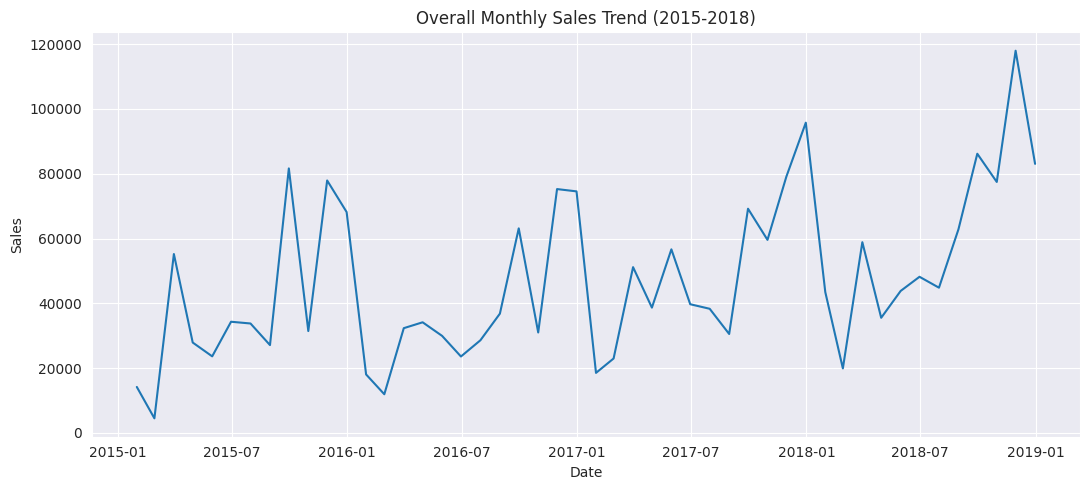

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

monthly = pd.read_csv('monthly_sales.csv', parse_dates=['Order Date']).set_index('Order Date')
monthly = monthly.asfreq('ME')

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly['Sales'])
plt.title('Overall Monthly Sales Trend (2015-2018)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('charts/task2_monthly_trend.png', dpi=110)
plt.show()

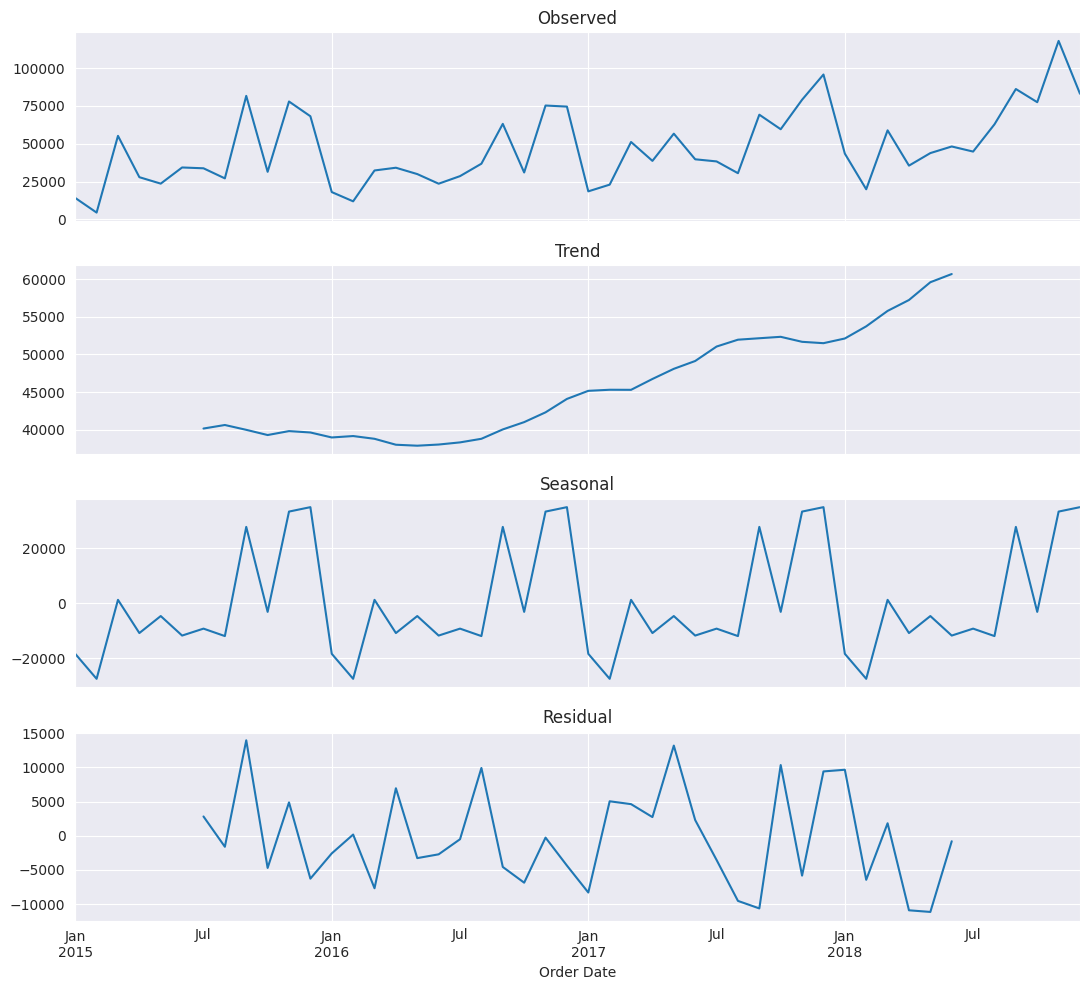

In [18]:
decomp = seasonal_decompose(monthly['Sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.savefig('charts/task2_decomposition.png', dpi=110)
plt.show()

In [19]:
print("Trend range:", round(decomp.trend.min(), 0), "to", round(decomp.trend.max(), 0))
print("Seasonal swing (max - min):", round(decomp.seasonal.max() - decomp.seasonal.min(), 0))
print("\nMonths with the highest residual (noise the model can't explain):")
decomp.resid.dropna().abs().sort_values(ascending=False).head()

Trend range: 37866.0 to 60701.0
Seasonal swing (max - min): 62195.0

Months with the highest residual (noise the model can't explain):


Order Date
2015-09-30    13970.933082
2017-05-31    13193.079793
2018-05-31    11157.549320
2018-04-30    10916.959724
2017-09-30    10642.715643
Name: resid, dtype: float64

### Stationarity check — Augmented Dickey-Fuller test



In [20]:
result = adfuller(monthly['Sales'].dropna())
print("ADF Statistic:", round(result[0], 4))
print("p-value:", result[1])
print("Critical values:", result[4])

ADF Statistic: -4.4161
p-value: 0.00027791039276670623
Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}


p-value comes out to about **0.00028**, well under 0.05, so technically this series is
already stationary — a bit surprising given how clear the trend line looked visually.
My guess is the trend component, while real, isn't strong enough relative to the
month-to-month variance to make the ADF test flag it as non-stationary. Task sheet
asks to apply differencing anyway, so doing that below and re-testing to see the effect.

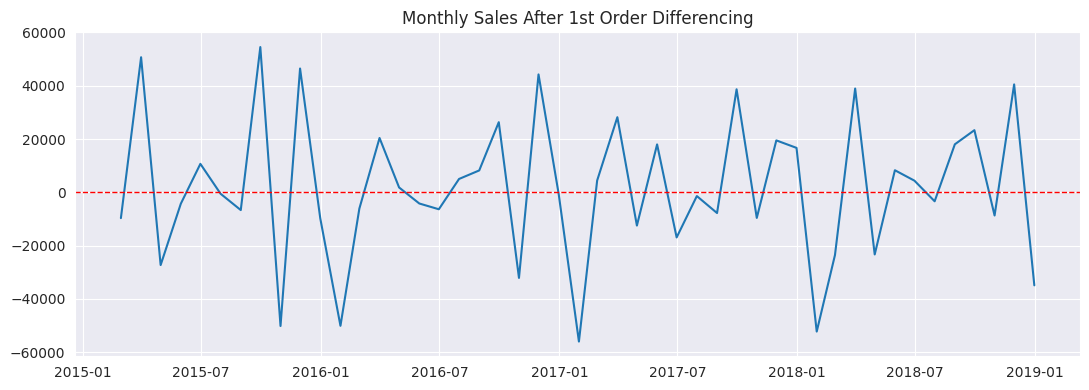

In [21]:
monthly['Sales_diff'] = monthly['Sales'].diff()

plt.figure(figsize=(11, 4))
plt.plot(monthly.index, monthly['Sales_diff'])
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Monthly Sales After 1st Order Differencing')
plt.tight_layout()
plt.savefig('charts/task2_differenced.png', dpi=110)
plt.show()

In [22]:
result_diff = adfuller(monthly['Sales_diff'].dropna())
print("ADF Statistic (after differencing):", round(result_diff[0], 4))
print("p-value (after differencing):", result_diff[1])

ADF Statistic (after differencing): -8.7271
p-value (after differencing): 3.2669175472796045e-14


After differencing, the p-value drops even further (from 2.8e-4 to 3.3e-14) and the
ADF statistic gets much more negative, so the differenced series is *more strongly*
stationary. Since the original series already passed the test, I'm using **d=0** for
the non-seasonal part of SARIMA in Task 3, but still expect to need seasonal
differencing (D=1) to properly strip out that 12-month cycle.

In [23]:
monthly.to_csv('monthly_with_diff.csv')

## Task 3 — Sales Forecasting using 3 Different Models

Splitting the last 3 months (Oct, Nov, Dec 2018) off as a test set so I can actually
measure how good each model is against real known values.


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

series = monthly['Sales']
train = series.iloc[:-3]
test = series.iloc[-3:]

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

print("Train:", len(train), "months | Test:", len(test), "months")
test

Train: 45 months | Test: 3 months


Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64

### Model 1 — SARIMA

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

candidates = [
    ((1, 0, 1), (1, 1, 1, 12)),
    ((1, 0, 0), (1, 1, 0, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (1, 1, 1, 12)),
    ((2, 0, 1), (1, 1, 1, 12)),
]

best_aic = np.inf
best_order = None
best_seasonal = None
for order, seasonal in candidates:
    m = SARIMAX(train, order=order, seasonal_order=seasonal,
                enforce_stationarity=False, enforce_invertibility=False)
    r = m.fit(disp=False)
    print(f"order={order} seasonal={seasonal}  ->  AIC={r.aic:.2f}")
    if r.aic < best_aic:
        best_aic = r.aic
        best_order = order
        best_seasonal = seasonal

print("\nBest:", best_order, best_seasonal, "AIC:", round(best_aic, 2))

order=(1, 0, 1) seasonal=(1, 1, 1, 12)  ->  AIC=417.36
order=(1, 0, 0) seasonal=(1, 1, 0, 12)  ->  AIC=444.00


order=(0, 1, 1) seasonal=(0, 1, 1, 12)  ->  AIC=395.41
order=(1, 1, 1) seasonal=(1, 1, 1, 12)  ->  AIC=398.78


order=(2, 0, 1) seasonal=(1, 1, 1, 12)  ->  AIC=419.29

Best: (0, 1, 1) (0, 1, 1, 12) AIC: 395.41


`(0,1,1)(0,1,1,12)` wins — interesting that it beat the models with AR terms, but this
is basically a seasonal moving-average model which makes sense for a series that's
mostly seasonal swing plus noise, not much autoregressive momentum month to month.

In [26]:
sarima_model = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_model.get_forecast(steps=3)
sarima_pred = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()
sarima_pred

2018-10-31    63675.434476
2018-11-30    90327.894154
2018-12-31    99547.199237
Freq: ME, Name: predicted_mean, dtype: float64

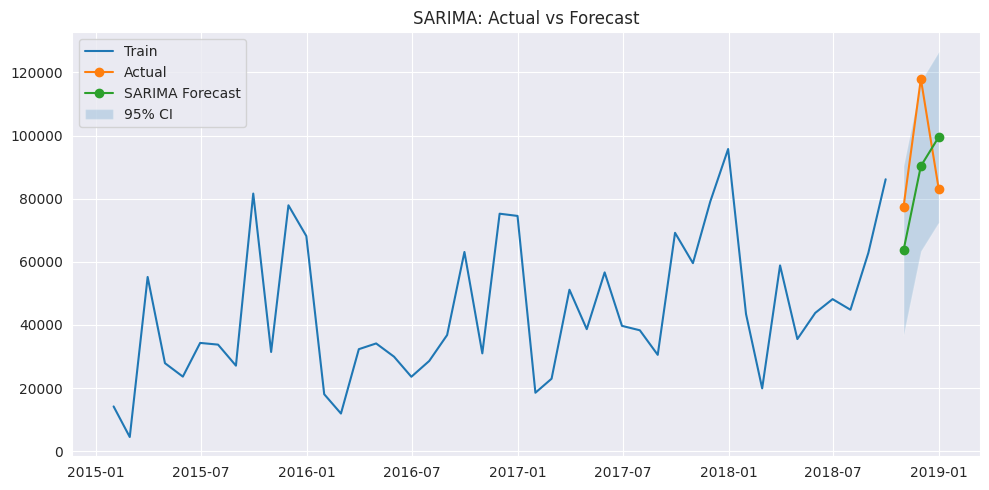

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', marker='o')
plt.plot(sarima_pred.index, sarima_pred, label='SARIMA Forecast', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.2, label='95% CI')
plt.legend()
plt.title('SARIMA: Actual vs Forecast')
plt.tight_layout()
plt.savefig('charts/task3_sarima.png', dpi=110)
plt.show()

In [28]:
sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mape(test.values, sarima_pred.values)
print(f"SARIMA -> MAE: {sarima_mae:.0f}, RMSE: {sarima_rmse:.0f}, MAPE: {sarima_mape:.2f}%")

SARIMA -> MAE: 19300, RMSE: 20206, MAPE: 20.36%


### Model 2 — Facebook Prophet

In [29]:
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
from prophet import Prophet

prophet_df = train.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=3, freq='ME')
forecast = prophet_model.predict(future)
prophet_pred = forecast.set_index('ds')['yhat'].iloc[-3:]
prophet_pred

13:35:06 - cmdstanpy - INFO - Chain [1] start processing


13:35:06 - cmdstanpy - INFO - Chain [1] done processing


ds
2018-10-31    51318.943803
2018-11-30    90325.654744
2018-12-31    90041.084284
Name: yhat, dtype: float64

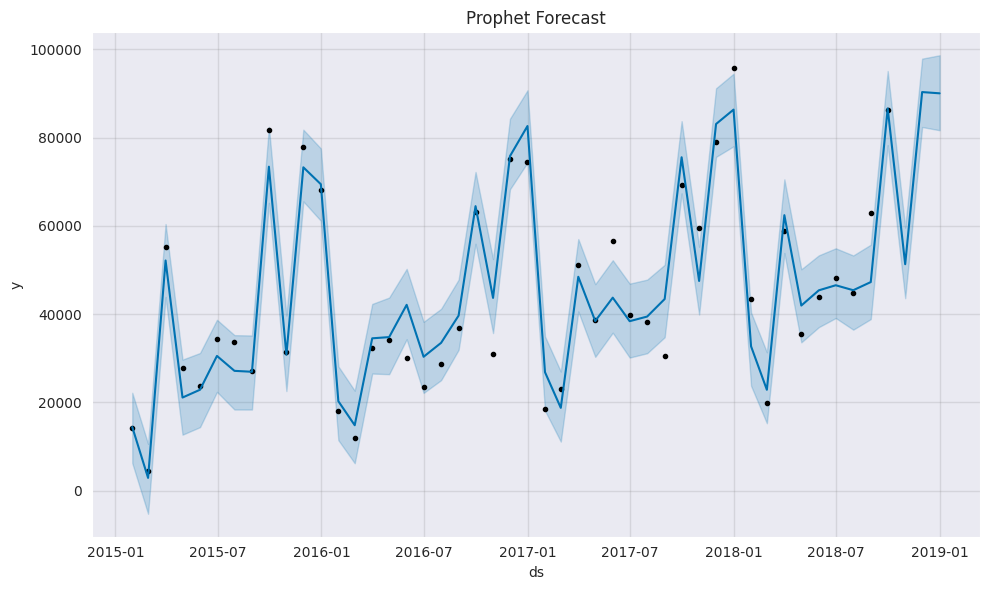

In [30]:
fig1 = prophet_model.plot(forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.savefig('charts/task3_prophet_forecast.png', dpi=110)
plt.show()

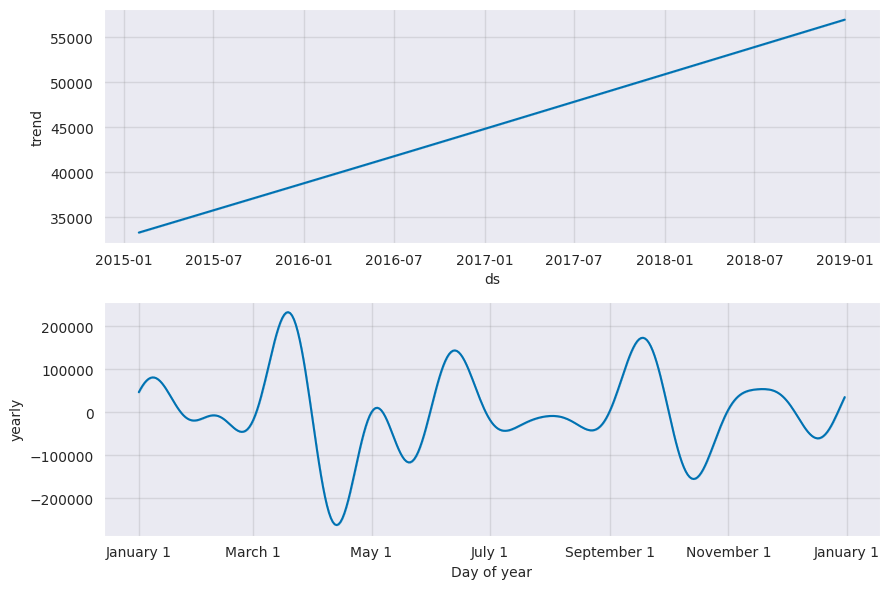

In [31]:
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.savefig('charts/task3_prophet_components.png', dpi=110)
plt.show()

The yearly seasonality component (bottom panel above) confirms the same Nov/Dec peak
and Jan/Feb dip that showed up in Task 1 and Task 2 — good sign that all three
approaches so far agree on the underlying pattern. Skipped weekly seasonality since
this data is aggregated to monthly, there's no weekly signal to extract from it.

In [32]:
prophet_mae = mean_absolute_error(test.values, prophet_pred.values)
prophet_rmse = np.sqrt(mean_squared_error(test.values, prophet_pred.values))
prophet_mape = mape(test.values, prophet_pred.values)
print(f"Prophet -> MAE: {prophet_mae:.0f}, RMSE: {prophet_rmse:.0f}, MAPE: {prophet_mape:.2f}%")

Prophet -> MAE: 20251, RMSE: 22318, MAPE: 21.86%


### Model 3 — XGBoost (lag-feature ML approach)

In [33]:
from xgboost import XGBRegressor

feat = monthly[['Sales']].copy()
feat['lag1'] = feat['Sales'].shift(1)
feat['lag2'] = feat['Sales'].shift(2)
feat['lag3'] = feat['Sales'].shift(3)
feat['rolling_mean3'] = feat['Sales'].shift(1).rolling(3).mean()
feat['Month'] = feat.index.month
feat['Quarter'] = feat.index.quarter

def season_num(m):
    if m in [12, 1, 2]: return 0
    elif m in [3, 4, 5]: return 1
    elif m in [6, 7, 8]: return 2
    else: return 3

feat['Season'] = feat['Month'].apply(season_num)
feat = feat.dropna()

feature_cols = ['lag1', 'lag2', 'lag3', 'rolling_mean3', 'Month', 'Quarter', 'Season']
xgb_train = feat.iloc[:-3]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(xgb_train[feature_cols], xgb_train['Sales'])

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [34]:
history = monthly['Sales'].iloc[:-3].tolist()
last_date = xgb_train.index[-1]
xgb_preds = []
for step in range(3):
    next_date = last_date + pd.offsets.MonthEnd(step + 1)
    row = pd.DataFrame([[history[-1], history[-2], history[-3], np.mean(history[-3:]),
                          next_date.month, next_date.quarter, season_num(next_date.month)]],
                        columns=feature_cols)
    pred = xgb_model.predict(row)[0]
    xgb_preds.append(pred)
    history.append(pred)

xgb_pred = pd.Series(xgb_preds, index=test.index)
xgb_pred

Order Date
2018-10-31    68952.867188
2018-11-30    87130.101562
2018-12-31    65684.359375
Freq: ME, dtype: float32

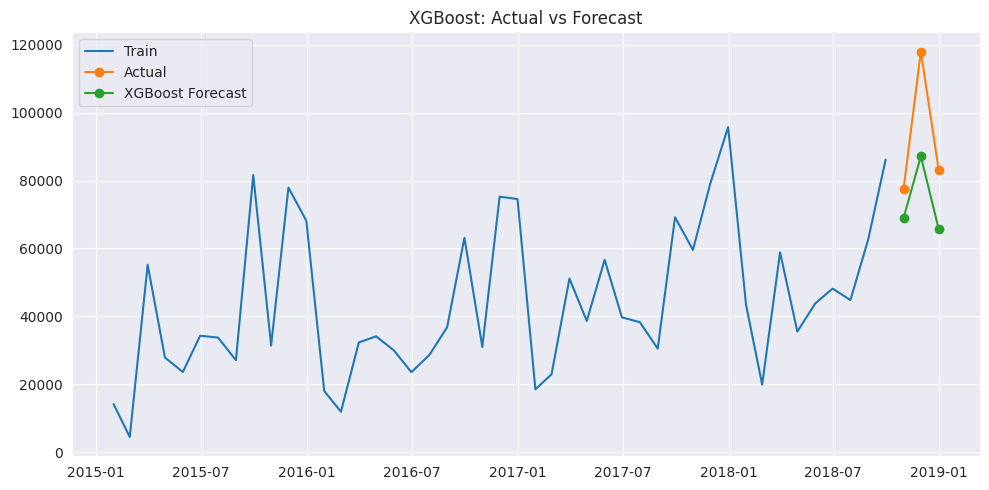

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', marker='o')
plt.plot(xgb_pred.index, xgb_pred, label='XGBoost Forecast', marker='o')
plt.legend()
plt.title('XGBoost: Actual vs Forecast')
plt.tight_layout()
plt.savefig('charts/task3_xgboost.png', dpi=110)
plt.show()

In [36]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

Month            0.738733
rolling_mean3    0.084278
lag2             0.079987
lag1             0.054607
lag3             0.038876
Season           0.003518
Quarter          0.000000
dtype: float32

Month dominates feature importance by a mile (~74%), which honestly just confirms
what we already knew — this data's behavior is almost entirely driven by which month
it is (seasonality), and the lag/rolling features are doing comparatively little work.

In [37]:
xgb_mae = mean_absolute_error(test.values, xgb_pred.values)
xgb_rmse = np.sqrt(mean_squared_error(test.values, xgb_pred.values))
xgb_mape = mape(test.values, xgb_pred.values)
print(f"XGBoost -> MAE: {xgb_mae:.0f}, RMSE: {xgb_rmse:.0f}, MAPE: {xgb_mape:.2f}%")

XGBoost -> MAE: 18883, RMSE: 20994, MAPE: 19.33%


### Model Comparison

In [38]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast Month 1': [sarima_pred.iloc[0], prophet_pred.iloc[0], xgb_pred.iloc[0]],
    'Forecast Month 2': [sarima_pred.iloc[1], prophet_pred.iloc[1], xgb_pred.iloc[1]],
    'Forecast Month 3': [sarima_pred.iloc[2], prophet_pred.iloc[2], xgb_pred.iloc[2]],
}).set_index('Model').round(1)
comparison

,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
Model,,,,,,
SARIMA,19299.9,20205.8,20.4,63675.4,90327.9,99547.2
Prophet,20250.8,22318.4,21.9,51318.9,90325.7,90041.1
XGBoost,18883.1,20993.6,19.3,68952.9,87130.1,65684.4


## Task 4 — Product Category & Region Level Forecasting


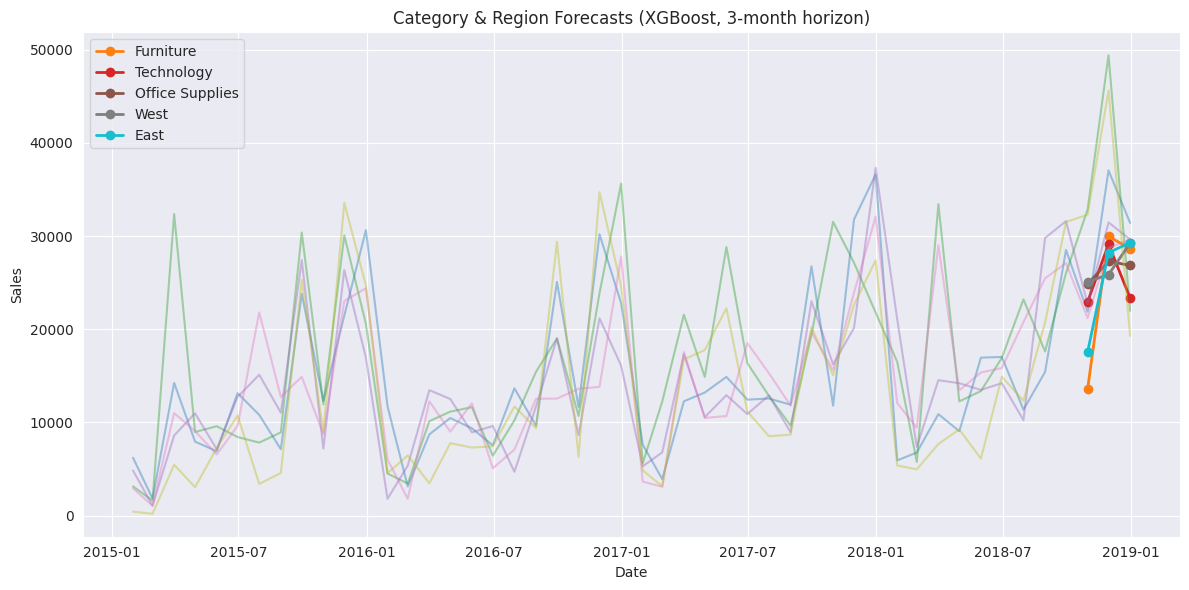

In [39]:
def forecast_segment(sub_df):
    seg_monthly = sub_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    seg_monthly = seg_monthly.asfreq('ME').fillna(0)

    d = pd.DataFrame({'Sales': seg_monthly})
    d['lag1'] = d['Sales'].shift(1)
    d['lag2'] = d['Sales'].shift(2)
    d['lag3'] = d['Sales'].shift(3)
    d['rolling_mean3'] = d['Sales'].shift(1).rolling(3).mean()
    d['Month'] = d.index.month
    d['Quarter'] = d.index.quarter
    d['Season'] = d['Month'].apply(season_num)
    d_feat = d.dropna()

    seg_train = d_feat.iloc[:-3]
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(seg_train[feature_cols], seg_train['Sales'])

    hist = d['Sales'].iloc[:-3].tolist()
    last = seg_train.index[-1]
    preds = []
    for step in range(3):
        nd = last + pd.offsets.MonthEnd(step + 1)
        row = pd.DataFrame([[hist[-1], hist[-2], hist[-3], np.mean(hist[-3:]),
                              nd.month, nd.quarter, season_num(nd.month)]], columns=feature_cols)
        p = model.predict(row)[0]
        preds.append(p)
        hist.append(p)
    idx = pd.date_range(last + pd.offsets.MonthEnd(1), periods=3, freq='ME')
    return seg_monthly, pd.Series(preds, index=idx)

segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East'],
}

plt.figure(figsize=(12, 6))
segment_summary = {}
for label, sub in segments.items():
    hist, preds = forecast_segment(sub)
    plt.plot(hist.index, hist.values, alpha=0.4)
    plt.plot(preds.index, preds.values, marker='o', linewidth=2, label=label)
    growth = (preds.iloc[-1] - hist.iloc[-1]) / hist.iloc[-1] * 100
    segment_summary[label] = {'forecast': preds.round(0).tolist(), 'growth_vs_last_actual': round(growth, 1)}

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Category & Region Forecasts (XGBoost, 3-month horizon)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task4_segment_forecasts.png', dpi=110)
plt.show()

In [40]:
for label, info in segment_summary.items():
    print(f"{label:18s} forecast={info['forecast']}  growth vs last actual month = {info['growth_vs_last_actual']}%")

Furniture          forecast=[13578.0, 29965.0, 28663.0]  growth vs last actual month = -8.7%
Technology         forecast=[22948.0, 29129.0, 23350.0]  growth vs last actual month = 6.2%
Office Supplies    forecast=[24838.0, 27293.0, 26857.0]  growth vs last actual month = -9.4%
West               forecast=[25108.0, 25863.0, 29254.0]  growth vs last actual month = -1.3%
East               forecast=[17566.0, 28222.0, 29304.0]  growth vs last actual month = 51.9%


## Task 5 — Anomaly Detection in Sales Data

In [41]:
from sklearn.ensemble import IsolationForest

weekly = pd.read_csv('weekly_sales.csv', parse_dates=['Order Date']).set_index('Order Date')
weekly = weekly.asfreq('W').fillna(0)

iso = IsolationForest(contamination=0.06, random_state=42)
weekly['iso_anomaly'] = iso.fit_predict(weekly[['Sales']])
iso_anomalies = weekly[weekly['iso_anomaly'] == -1]
print(f"Isolation Forest flagged {len(iso_anomalies)} anomalous weeks")
iso_anomalies[['Sales']]

Isolation Forest flagged 13 anomalous weeks


,Sales
Order Date,
2015-01-04,304.5080
2015-02-08,968.5340
2015-02-22,224.9120
2015-03-22,37703.6650
2015-07-19,1387.6860
2015-09-13,29959.1370
2015-11-22,26793.6235
2016-01-24,358.5220
2017-10-08,28412.0980


Used `contamination=0.06` (~6% of weeks) instead of the default 0.1 — with 209 weeks
of data, 10% felt like it would flag too many normal high-season weeks as "anomalies"
when they're really just expected seasonal peaks.

In [42]:
weekly['rolling_mean'] = weekly['Sales'].rolling(8, center=True, min_periods=1).mean()
weekly['rolling_std'] = weekly['Sales'].rolling(8, center=True, min_periods=1).std()
weekly['zscore'] = (weekly['Sales'] - weekly['rolling_mean']) / weekly['rolling_std']

z_anomalies = weekly[weekly['zscore'].abs() > 2]
print(f"Z-score method flagged {len(z_anomalies)} anomalous weeks")
z_anomalies[['Sales', 'zscore']]

Z-score method flagged 6 anomalous weeks


,Sales,zscore
Order Date,,
2015-03-22,37703.665,2.384855
2015-07-26,21590.080,2.088711
2016-03-20,13310.136,2.209014
2017-02-05,17926.368,2.419527
2017-05-28,23367.662,2.105511
2017-10-08,28412.098,2.128709


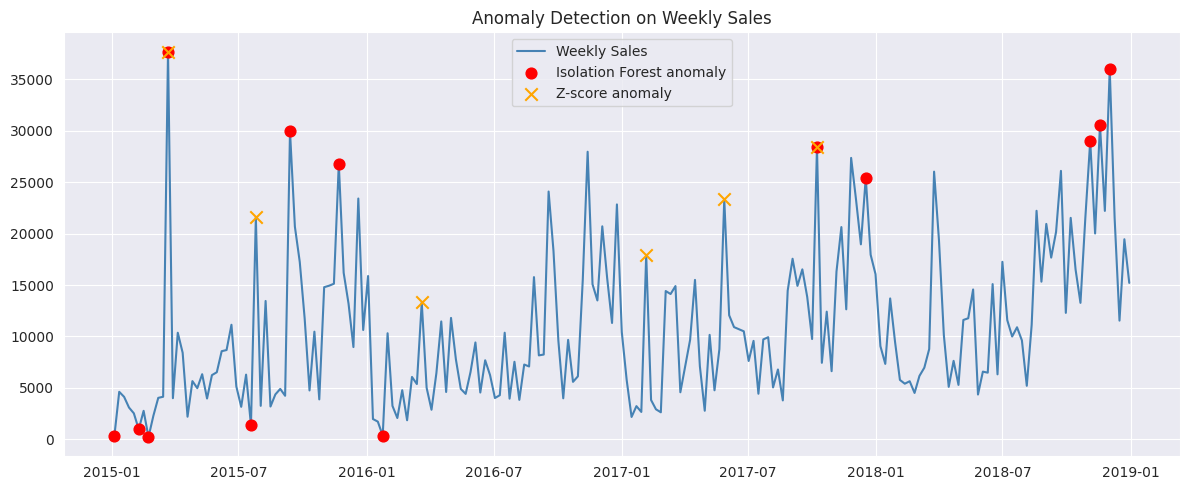

In [43]:
plt.figure(figsize=(12, 5))
plt.plot(weekly.index, weekly['Sales'], label='Weekly Sales', color='steelblue')
plt.scatter(iso_anomalies.index, iso_anomalies['Sales'], color='red',
            label='Isolation Forest anomaly', zorder=5, s=60)
plt.scatter(z_anomalies.index, z_anomalies['Sales'], color='orange', marker='x',
            label='Z-score anomaly', zorder=5, s=80)
plt.legend()
plt.title('Anomaly Detection on Weekly Sales')
plt.tight_layout()
plt.savefig('charts/task5_anomalies.png', dpi=110)
plt.show()

In [44]:
common = sorted(set(iso_anomalies.index) & set(z_anomalies.index))
print(f"Weeks flagged by BOTH methods: {len(common)}")
for d in common:
    print(" -", d.date())

Weeks flagged by BOTH methods: 2
 - 2015-03-22
 - 2017-10-08


**Only 2 weeks overlap** (22 Mar 2015 and 8 Oct 2017) out of 13 flagged by Isolation
Forest and 6 by Z-score. That's a bigger disagreement than I expected, and it makes
sense once you think about what each method actually does:

- **Isolation Forest** looks at the whole distribution of sales values and isolates
  points that are rare in absolute terms — so it flags both unusually *high* weeks
  AND unusually *low* weeks (several of its flagged weeks are near-zero sales weeks
  early on, e.g. Jan/Feb 2015).
- **Z-score here is relative to a rolling local average**, so it only flags a week as
  anomalous if it's a sharp spike or dip *compared to its own neighborhood in time* —
  a genuinely low week in a already-low season won't get flagged because the rolling
  mean around it is also low.

So the two methods aren't measuring the same thing, one is "rare in general", the
other is "surprising given the recent trend". That's actually useful — the 2 weeks
both agree on are the most confidently anomalous.

**Likely real-world explanations** for a few of the top flagged weeks:
- **22 Mar 2015** (₹37,704, top anomaly by both methods) — likely a large one-off bulk
  order (e.g. a corporate client), since this is way outside the normal March range.
- **8 Oct 2017** (₹28,412) — could be an early promotional push ahead of the Nov/Dec
  holiday season.
- The very low near-zero weeks in Jan/Feb 2015 are most likely just the business still
  ramping up in its first year rather than a real demand signal.

## Task 6 — Product Demand Segmentation using Clustering

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

subcats = df['Sub-Category'].unique()
rows = []
for sc in subcats:
    sub = df[df['Sub-Category'] == sc]
    total_sales = sub['Sales'].sum()
    avg_order_value = sub['Sales'].mean()

    sc_monthly = sub.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    sc_monthly = sc_monthly.reindex(pd.date_range(df['Order Date'].min(), df['Order Date'].max(), freq='ME')).fillna(0)
    volatility = sc_monthly.std()

    yearly = sub.groupby(sub['Order Date'].dt.year)['Sales'].sum().sort_index()
    growth_rate = (yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0] * 100 if yearly.iloc[0] > 0 else 0

    rows.append({'Sub-Category': sc, 'total_sales': total_sales, 'growth_rate': growth_rate,
                 'volatility': volatility, 'avg_order_value': avg_order_value})

seg_df = pd.DataFrame(rows).set_index('Sub-Category')
seg_df.round(1)

,total_sales,growth_rate,volatility,avg_order_value
Sub-Category,,,,
Bookcases,113813.2,49.8,2245.3,503.6
Chairs,322822.7,21.0,4282.3,531.8
Labels,12347.7,36.1,225.9,34.6
Tables,202810.6,33.1,3189.2,645.9
Storage,219343.4,38.4,2726.4,263.6
Furnishings,89212.0,106.8,1335.0,95.8
Art,26705.4,49.6,330.9,34.0
Phones,327782.4,35.6,4082.9,374.2
Binders,200028.8,65.8,3888.8,134.1


Quick note on `avg_order_value` — the dataset doesn't have a clean "order total"
column separate from line items, so I'm using average line-item sale value per
sub-category as a stand-in. Not perfect, but it's a reasonable proxy for "how
expensive is a typical purchase in this sub-category" which is what this feature is
meant to capture.

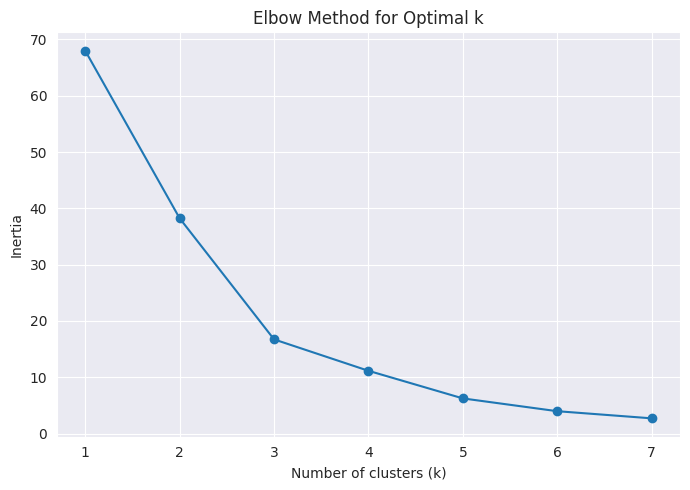

In [46]:
features = ['total_sales', 'growth_rate', 'volatility', 'avg_order_value']
X_scaled = StandardScaler().fit_transform(seg_df[features].values)

inertias = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 8), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/task6_elbow.png', dpi=110)
plt.show()

The elbow isn't razor sharp (it's a fairly smooth curve, only 17 sub-categories to
work with so that's expected), but the bend visibly softens after k=4. Going with
**k=4** — also happens to line up with the 4 example labels given in the task sheet
(High Volume/Stable, Low Volume/Volatile, Growing, Declining), which is a good sign.

In [47]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_df['cluster'] = km.fit_predict(X_scaled)
seg_df.groupby('cluster')[features].mean().round(1)

,total_sales,growth_rate,volatility,avg_order_value
cluster,,,,
0,46907.8,59.9,855.6,97.6
1,189238.6,-29.8,5433.3,1645.6
2,221541.1,55.5,3287.5,381.5
3,146248.1,479.7,4994.2,2215.9


In [48]:
for c in sorted(seg_df['cluster'].unique()):
    print(f"Cluster {c}:", list(seg_df[seg_df['cluster'] == c].index))

Cluster 0: ['Labels', 'Furnishings', 'Art', 'Appliances', 'Paper', 'Envelopes', 'Fasteners', 'Supplies']
Cluster 1: ['Machines']
Cluster 2: ['Bookcases', 'Chairs', 'Tables', 'Storage', 'Phones', 'Binders', 'Accessories']
Cluster 3: ['Copiers']


Explained variance ratio: [0.612 0.287]


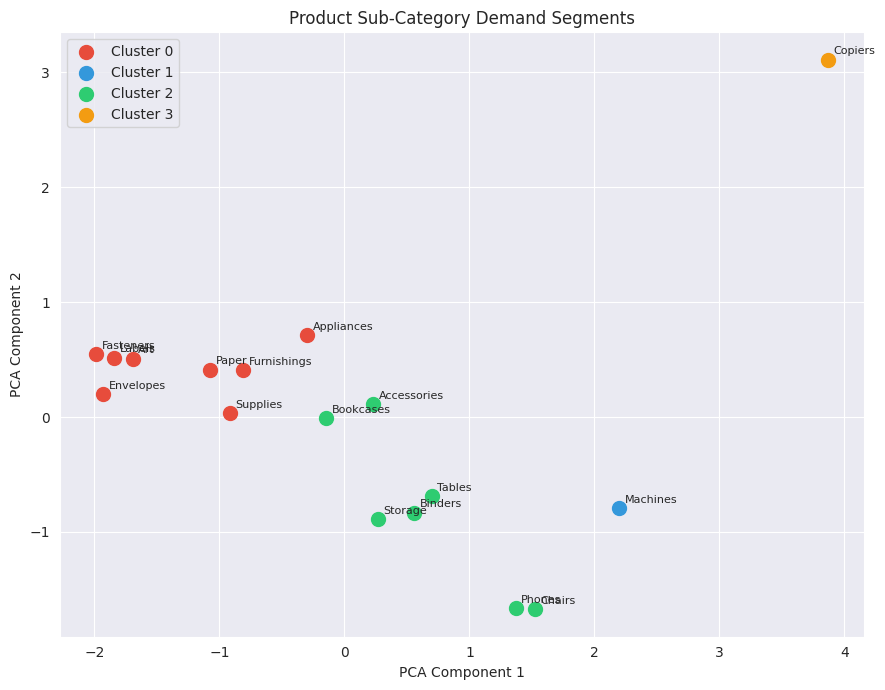

In [49]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
seg_df['pca1'], seg_df['pca2'] = coords[:, 0], coords[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

plt.figure(figsize=(9, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for c in sorted(seg_df['cluster'].unique()):
    sub = seg_df[seg_df['cluster'] == c]
    plt.scatter(sub['pca1'], sub['pca2'], label=f'Cluster {c}', s=100, color=colors[c % 4])
    for name, row in sub.iterrows():
        plt.annotate(name, (row['pca1'], row['pca2']), fontsize=8, xytext=(4, 4), textcoords='offset points')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Product Sub-Category Demand Segments')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task6_clusters.png', dpi=110)
plt.show()

The two PCA components capture about 89% of the variance (61% + 29%), so this 2D plot
is a fair representation of the actual 4D clustering, not a huge distortion.

**Cluster labels, based on what's actually in each group:**

- **Cluster 2 — High Volume, Growing Demand** (Bookcases, Chairs, Tables, Storage,
  Phones, Binders, Accessories): the core of the business — highest total sales
  (₹2.2L avg), solid growth (+55%), moderate order value. **Stocking strategy:** keep
  healthy safety stock, these can't afford to go out of stock.
- **Cluster 0 — Low Volume, Stable Demand** (Labels, Furnishings, Art, Appliances,
  Paper, Envelopes, Fasteners, Supplies): smallest total sales (~₹47k avg), lowest
  volatility of any group, cheap items. **Stocking strategy:** lean/just-in-time stock,
  low risk either way since demand barely fluctuates.
- **Cluster 3 — Copiers (explosive growth, high value)**: only item here, but it's a
  standout — +480% growth and by far the highest average order value (₹2,216).
  **Stocking strategy:** don't over-order based on historical averages, this is
  trending hard and needs demand forecasting revisited every quarter, not stocked on
  autopilot.
- **Cluster 1 — Machines (declining, high value)**: also a single-item cluster —
  total sales are respectable (₹1.9L) but growth is *negative* (-30%) with high
  volatility. **Stocking strategy:** actively reduce stock levels and avoid tying up
  capital here, this is a category to wind down, not build up.

## Task 7 — Deployment: Interactive Dashboard

Built as a separate file, `app.py`, using Streamlit — a notebook isn't the right place
for an interactive multi-page dashboard. It has 4 pages (Sales Overview, Forecast
Explorer, Anomaly Report, Product Demand Segments) matching the task brief, and reuses
the same XGBoost forecasting logic and anomaly/cluster results built above. To run it
locally:
```
pip install -r requirements.txt
streamlit run app.py
```


## Task 8 — Executive Business Report

Written separately as `summary.docx` — a 2-page report for a non-technical audience
(Head of Supply Chain / CFO), covering the executive summary, key EDA + forecasting
findings, the 3-month forecast in plain language, top anomalies, segmentation
strategy, business recommendations, and limitations.

## Wrap-up

All 8 tasks are done. Quick honest note on what I'd improve with more time: the
XGBoost recursive forecast only has 45 monthly data points to train on, which is thin
for a tree-based model — with more historical data (or daily-level features instead of
monthly) I'd expect all three models to tighten up their error margins. Also didn't
get to tune Prophet's changepoint/seasonality-strength hyperparameters, just used
defaults with yearly seasonality on, that's a likely next step if this needed to be
more production-grade.